# Economic Burden Steel Tariffs have on Consumers

$$
\text{Price Change}
\times
\text{Transaction Quantity}
$$

This gives an approximation of additional spending due to tariffs (**consumer cost estimate**)


$$
\text{Total Cost Increase}_{year} =
(\text{Price}_{after} - \text{Price}_{before}) \times \text{Quantity}_{year}
$$


Where:



$$
\text{Total Cost Impact}_{year} =
\text{Price Change} \times \text{Transaction Quantity}
$$

In [102]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [103]:
df = pd.read_csv(r"C:\Users\melis\OneDrive - Dartmouth College\Documents\GitHub\QSS20_Group_Project\steel_price\STEEL_PRICE_rebased.csv", low_memory = False)
# load steel quantity data

qty = pd.read_csv("STEEL_PRICE_rebased.csv")

#merge
df["DATE"] = pd.to_datetime(df["DATE"])
qty["DATE"] = pd.to_datetime(qty["DATE"])

df = df.merge(qty, on="DATE", how="left")

df = df.rename(columns={
    "VALUE_x": "steel_price",
    "VALUE_y": "quantity"
})

In [104]:
print(df.columns)

Index(['DATE', 'steel_price', 'VALUE_2015_BASE_x', 'quantity',
       'VALUE_2015_BASE_y'],
      dtype='object')


In [105]:
# convert index back to actual price change relative to baseline
df["price_change"] = df["steel_price"] - df["VALUE_2015_BASE_x"]
df["consumer_cost"] = df["price_change"] * df["quantity"]

In [106]:
# estimate consumer cost from price increases
df["consumer_cost"] = df["price_change"] * df["quantity"]

In [107]:
df["year"] = df["DATE"].dt.year

yearly_cost = df.groupby("year")["consumer_cost"].sum()

print(yearly_cost)

year
2015    208570.76
2016    164254.47
2017    193869.42
2018    258171.55
2019    256289.13
Name: consumer_cost, dtype: float64


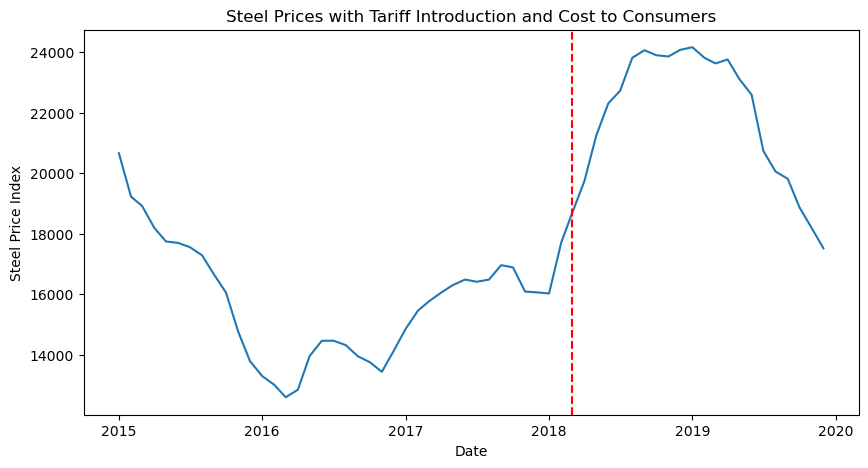

In [108]:
plt.figure(figsize=(10,5))
plt.plot(df["DATE"], df["consumer_cost"])
plt.axvline(pd.to_datetime("2018-03-01"), color="red", linestyle="--")
plt.xlabel("Date")
plt.ylabel("Steel Price Index")
plt.title("Steel Prices with Tariff Introduction and Cost to Consumers")

plt.savefig("steel_consumer_cost_plot.png", dpi=300, bbox_inches="tight")

plt.show()

In [109]:
df["year"] = df["DATE"].dt.year

yearly_quantity = df.groupby("year")["quantity"].sum().reset_index()
print(yearly_quantity)

   year  quantity
0  2015    2222.1
1  2016    1974.2
2  2017    2144.9
3  2018    2470.7
4  2019    2462.8


In [110]:
df["price_change"] = df["VALUE_2015_BASE_x"] - 100

In [111]:
df["cost_impact"] = df["price_change"] * df["quantity"]

In [112]:
yearly_cost = df.groupby("year")["cost_impact"].sum().reset_index()

print(yearly_cost)

   year  cost_impact
0  2015    -18151.15
1  2016    -36720.43
2  2017    -24857.91
3  2018      5582.04
4  2019      4411.71


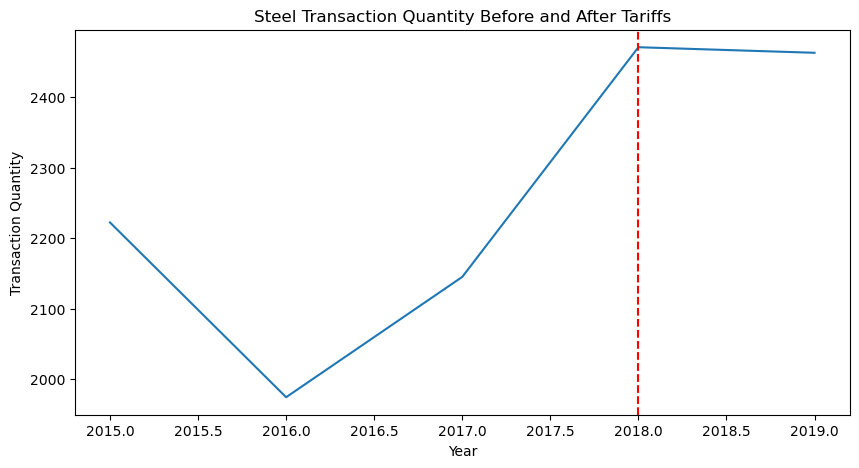

In [113]:
plt.figure(figsize=(10,5))
plt.plot(yearly_quantity["year"], yearly_quantity["quantity"])
plt.axvline(2018, color="red", linestyle="--")
plt.title("Steel Transaction Quantity Before and After Tariffs")
plt.xlabel("Year")
plt.ylabel("Transaction Quantity")


plt.savefig("steel_transactions_plot.png", dpi=300, bbox_inches="tight")

plt.show()


In [114]:
df["year_month"] = df["DATE"].dt.strftime("%Y-%m")

# calculate monthly total quantity
monthly_quantity_table = df.groupby("year_month")["quantity"].sum().reset_index()

# display table
print(monthly_quantity_table)

   year_month  quantity
0     2015-01     202.2
1     2015-02     195.0
2     2015-03     193.5
3     2015-04     189.8
4     2015-05     187.4
5     2015-06     187.1
6     2015-07     186.4
7     2015-08     184.9
8     2015-09     181.5
9     2015-10     178.2
10    2015-11     170.9
11    2015-12     165.2
12    2016-01     162.2
13    2016-02     160.4
14    2016-03     157.9
15    2016-04     159.4
16    2016-05     166.2
17    2016-06     169.2
18    2016-07     169.2
19    2016-08     168.3
20    2016-09     166.1
21    2016-10     165.0
22    2016-11     163.1
23    2016-12     167.2
24    2017-01     171.5
25    2017-02     174.9
26    2017-03     176.6
27    2017-04     178.2
28    2017-05     179.6
29    2017-06     180.6
30    2017-07     180.2
31    2017-08     180.6
32    2017-09     183.2
33    2017-10     182.8
34    2017-11     178.4
35    2017-12     178.3
36    2018-01     178.1
37    2018-02     187.2
38    2018-03     192.3
39    2018-04     197.6
40    2018-05   

In [115]:
monthly_quantity_table["DATE"] = pd.to_datetime(monthly_quantity_table["year_month"])

# keep every 6th month
reduced_table = monthly_quantity_table.iloc[::6]

latex_table = reduced_table.to_latex(index=False)
with open("steel_transactions_table.tex", "w") as f:
    f.write(latex_table)

reduced_table


,year_month,quantity,DATE
0,2015-01,202.2,2015-01-01
6,2015-07,186.4,2015-07-01
12,2016-01,162.2,2016-01-01
18,2016-07,169.2,2016-07-01
24,2017-01,171.5,2017-01-01
30,2017-07,180.2,2017-07-01
36,2018-01,178.1,2018-01-01
42,2018-07,212.0,2018-07-01
48,2019-01,218.7,2019-01-01
54,2019-07,202.5,2019-07-01
